# 04 — Neural networks and backpropagation

This is the centre of the repo. Everything before it was preparation.

Chapter 03 ended on a wall: logistic regression draws a straight line, and XOR
cannot be separated by a straight line. The fix is to stack layers with a
**non-linearity** between them — and the cost of that fix is that we now need
**backpropagation** to compute gradients.

Backprop is not a new idea. It is the chain rule, applied systematically, with
intermediate results cached so nothing is computed twice.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

## Why the non-linearity is not optional

Stack two linear layers: $W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$.

That is a single linear layer with weights $W_2 W_1$. A hundred stacked linear
layers collapse to one. Depth buys you nothing without a non-linearity in between.

In [2]:
W1 = rng.normal(size=(3, 4))
W2 = rng.normal(size=(4, 2))
x = rng.normal(size=(5, 3))

two_layers = (x @ W1) @ W2
collapsed  = x @ (W1 @ W2)

print("identical:", np.allclose(two_layers, collapsed))
print("-> two linear layers ARE one linear layer")

identical: True
-> two linear layers ARE one linear layer


## ReLU

$$\text{ReLU}(z) = \max(0, z)$$

Nearly the simplest non-linearity that works. Its derivative is 1 for positive
inputs and 0 otherwise — no saturation on the positive side, which is exactly
what sigmoid got wrong. Gradients flow through deep stacks without shrinking.

The cost: units stuck at negative pre-activations have zero gradient forever
("dying ReLU"). Leaky ReLU exists for this reason.

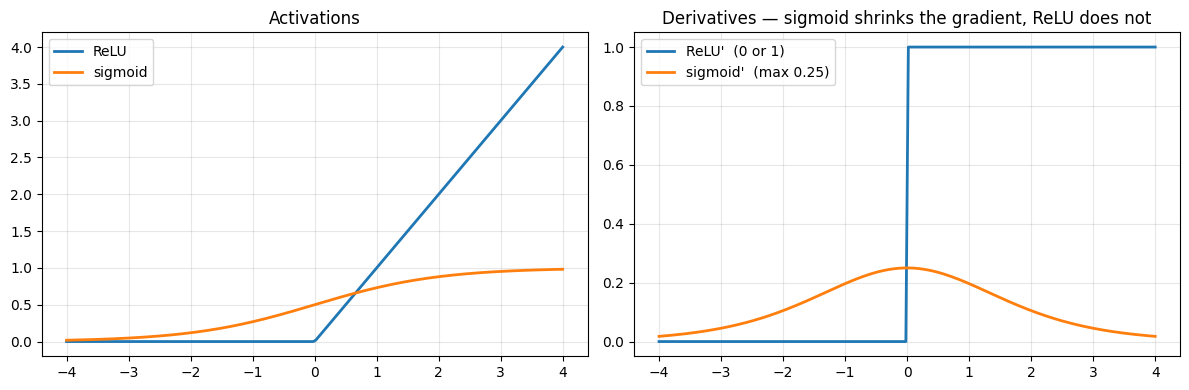

0.25^10 = 9.54e-07  <- the vanishing gradient problem, in one number


In [3]:
from mlscratch.activations import relu, relu_prime, sigmoid, sigmoid_prime_from_output

z = np.linspace(-4, 4, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, relu(z), lw=2, label="ReLU")
axes[0].plot(z, sigmoid(z), lw=2, label="sigmoid")
axes[0].set_title("Activations"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(z, relu_prime(z), lw=2, label="ReLU'  (0 or 1)")
axes[1].plot(z, sigmoid_prime_from_output(sigmoid(z)), lw=2, label="sigmoid'  (max 0.25)")
axes[1].set_title("Derivatives — sigmoid shrinks the gradient, ReLU does not")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Compounding matters: 10 sigmoid layers at peak derivative.
print(f"0.25^10 = {0.25 ** 10:.2e}  <- the vanishing gradient problem, in one number")

## Forward pass

For a network with layers $0 \ldots L-1$:

$$z^{(i)} = a^{(i)} W^{(i)} + b^{(i)}, \qquad a^{(i+1)} = g(z^{(i)})$$

with ReLU for hidden layers and softmax at the output. We **cache** every $z$ and
$a$, because backprop needs them and recomputing would double the work.

**He initialisation.** Weights are drawn from $\mathcal{N}(0, 2/n_{in})$. Too small
and the signal dies as it propagates; too large and it explodes. The factor of 2
compensates for ReLU zeroing out half the activations.

In [4]:
from mlscratch.activations import softmax

def init_params(layer_sizes, seed=0):
    rng_local = np.random.default_rng(seed)
    params = {}
    for i in range(len(layer_sizes) - 1):
        fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
        params[f"W{i}"] = rng_local.normal(0, np.sqrt(2.0 / fan_in), (fan_in, fan_out))
        params[f"b{i}"] = np.zeros(fan_out)
    return params

def forward(X, params, n_layers):
    cache = {"a0": X}
    a = X
    for i in range(n_layers):
        z = a @ params[f"W{i}"] + params[f"b{i}"]
        cache[f"z{i}"] = z
        a = softmax(z) if i == n_layers - 1 else relu(z)
        cache[f"a{i+1}"] = a
    return a, cache

params = init_params([2, 8, 2], seed=0)
probs, cache = forward(rng.normal(size=(4, 2)), params, n_layers=2)

print("output shape:", probs.shape)
print("rows sum to 1:", np.allclose(probs.sum(axis=1), 1.0))
print("cached keys:", sorted(cache.keys()))

output shape: (4, 2)
rows sum to 1: True
cached keys: ['a0', 'a1', 'a2', 'z0', 'z1']


## Backward pass

We want $\partial L / \partial W^{(i)}$ for every layer. The chain rule gives it,
but the order matters: compute from the output backwards, reusing each result.

**The starting point.** With softmax output and cross-entropy loss, the gradient
with respect to the *logits* is astonishingly simple:

$$\frac{\partial L}{\partial z^{(L-1)}} = \frac{p - y}{n}$$

The softmax Jacobian and the cross-entropy derivative cancel exactly. This is the
same cancellation we saw in chapter 03, generalised.

**Then, layer by layer:**

$$\frac{\partial L}{\partial W^{(i)}} = (a^{(i)})^\top \delta^{(i)}$$
$$\delta^{(i-1)} = \big(\delta^{(i)} (W^{(i)})^\top\big) \odot g'(z^{(i-1)})$$

Read the second line as: push the error back through the weights, then mask it by
where the activation was actually alive.

In [5]:
from mlscratch.losses import softmax_cross_entropy_grad

def backward(y_onehot, cache, params, n_layers):
    grads = {}
    delta = softmax_cross_entropy_grad(y_onehot, cache[f"a{n_layers}"])

    for i in reversed(range(n_layers)):
        grads[f"W{i}"] = cache[f"a{i}"].T @ delta      # (fan_in, n) @ (n, fan_out)
        grads[f"b{i}"] = delta.sum(axis=0)
        if i > 0:
            delta = (delta @ params[f"W{i}"].T) * relu_prime(cache[f"z{i-1}"])

    return grads

### Gradient checking — do not skip this

A wrong backprop implementation still trains. The loss still goes down. You get a
model that works *worse than it should* and no error message telling you why.

Finite differences are the ground truth:

$$\frac{\partial f}{\partial x} \approx \frac{f(x+h) - f(x-h)}{2h}$$

Too slow for training, perfect for a test. Relative error below `1e-7` means the
analytic gradient is correct.

In [6]:
from mlscratch.utils import numerical_gradient, one_hot, relative_error

X_small = rng.normal(size=(5, 2))
y_small = one_hot(rng.integers(0, 2, 5), 2)
params_check = init_params([2, 4, 2], seed=1)
n_layers = 2

probs, cache = forward(X_small, params_check, n_layers)
grads = backward(y_small, cache, params_check, n_layers)

def loss_with(key, value):
    saved = params_check[key].copy()
    params_check[key] = value
    p, _ = forward(X_small, params_check, n_layers)
    params_check[key] = saved
    return -np.sum(y_small * np.log(np.clip(p, 1e-12, 1))) / y_small.shape[0]

print(f"{'param':>6} {'rel. error':>12}   status")
print("-" * 34)
all_ok = True
for key in sorted(params_check):
    numeric = numerical_gradient(lambda v, k=key: loss_with(k, v), params_check[key].copy())
    err = relative_error(grads[key], numeric)
    ok = err < 1e-6
    all_ok &= ok
    print(f"{key:>6} {err:>12.2e}   {'PASS' if ok else 'FAIL'}")

print("\nBackprop is correct." if all_ok else "\nSomething is wrong.")

 param   rel. error   status
----------------------------------
    W0     1.18e-08   PASS
    W1     5.00e-11   PASS
    b0     1.40e-09   PASS
    b1     1.07e-11   PASS

Backprop is correct.


## Solve XOR — the problem that broke chapter 03

In [7]:
from mlscratch.losses import cross_entropy
from mlscratch.optim import Adam

X_xor = np.array([[0.0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])
Y_xor = one_hot(y_xor, 2)

params = init_params([2, 8, 2], seed=3)
opt = Adam(lr=0.05)
losses = []

for epoch in range(600):
    probs, cache = forward(X_xor, params, n_layers=2)
    losses.append(cross_entropy(Y_xor, probs))
    grads = backward(Y_xor, cache, params, n_layers=2)
    params = opt.step(params, grads)

probs, _ = forward(X_xor, params, n_layers=2)
print("input      true   P(class 1)")
for xi, yi, pi in zip(X_xor, y_xor, probs[:, 1]):
    print(f"{xi}   {yi}      {pi:.4f}")
print(f"\nfinal loss: {losses[-1]:.6f}   (chapter 03 was stuck at 0.693)")

input      true   P(class 1)
[0. 0.]   0      0.0010
[0. 1.]   1      0.9997
[1. 0.]   1      0.9998
[1. 1.]   0      0.0010

final loss: 0.000613   (chapter 03 was stuck at 0.693)


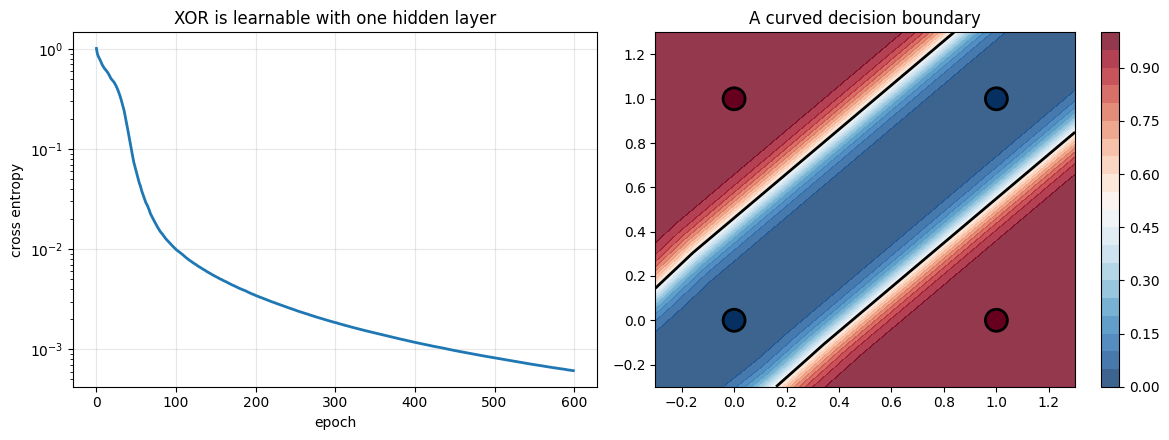

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(losses, lw=2)
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross entropy")
axes[0].set_title("XOR is learnable with one hidden layer"); axes[0].grid(alpha=0.3)

xx, yy = np.meshgrid(np.linspace(-0.3, 1.3, 200), np.linspace(-0.3, 1.3, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz, _ = forward(grid, params, n_layers=2)
zz = zz[:, 1].reshape(xx.shape)

cs = axes[1].contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.8)
axes[1].contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
axes[1].scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor, cmap="RdBu_r",
                s=250, edgecolors="k", linewidths=2)
axes[1].set_title("A curved decision boundary")
plt.colorbar(cs, ax=axes[1]); plt.tight_layout(); plt.show()

The boundary is no longer a line. The hidden layer learned a representation in
which the problem *became* linearly separable, and the output layer drew the line
there.

That sentence is, more or less, all of deep learning.

## Scale up: two moons

In [9]:
def make_moons(n=600, noise=0.2, seed=0):
    """Two interleaving half-circles. Classic non-linear benchmark."""
    r = np.random.default_rng(seed)
    n_out = n // 2
    n_in = n - n_out
    theta_out = np.pi * r.uniform(0, 1, n_out)
    theta_in = np.pi * r.uniform(0, 1, n_in)
    X = np.vstack([
        np.c_[np.cos(theta_out), np.sin(theta_out)],
        np.c_[1 - np.cos(theta_in), 0.5 - np.sin(theta_in)],
    ])
    X += r.normal(0, noise, X.shape)
    y = np.hstack([np.zeros(n_out, int), np.ones(n_in, int)])
    return X, y

from mlscratch.models import NeuralNetwork
from mlscratch.metrics import accuracy
from mlscratch.utils import standardize, train_test_split

X_m, y_m = make_moons(600, noise=0.2, seed=7)
X_tr, X_te, y_tr, y_te = train_test_split(X_m, y_m, test_size=0.25, seed=0)
X_tr, mu, sd = standardize(X_tr)
X_te, _, _ = standardize(X_te, mu, sd)

net = NeuralNetwork([2, 32, 16, 2], seed=0)
net.fit(X_tr, y_tr, epochs=150, batch_size=32, optimizer=Adam(lr=0.01))

print(f"train accuracy: {accuracy(y_tr, net.predict(X_tr)):.3f}")
print(f"test  accuracy: {accuracy(y_te, net.predict(X_te)):.3f}")

train accuracy: 0.976
test  accuracy: 0.953


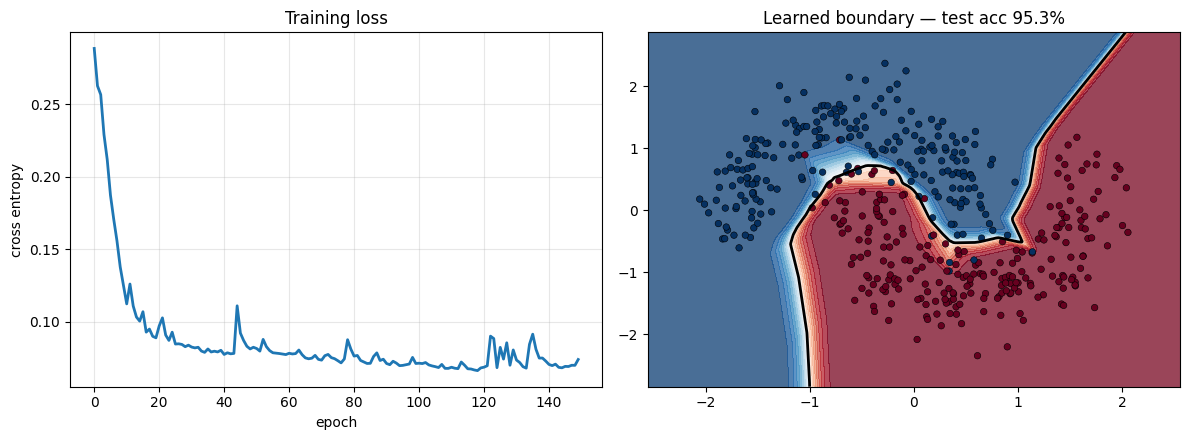

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(net.history, lw=2)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross entropy")
axes[0].set_title("Training loss"); axes[0].grid(alpha=0.3)

xx, yy = np.meshgrid(np.linspace(X_tr[:, 0].min()-.5, X_tr[:, 0].max()+.5, 250),
                     np.linspace(X_tr[:, 1].min()-.5, X_tr[:, 1].max()+.5, 250))
probs, _ = net.forward(np.c_[xx.ravel(), yy.ravel()])
zz = probs[:, 1].reshape(xx.shape)

axes[1].contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.75)
axes[1].contour(xx, yy, zz, levels=[0.5], colors="k", linewidths=2)
axes[1].scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="RdBu_r",
                edgecolors="k", s=22, linewidths=0.4)
axes[1].set_title(f"Learned boundary — test acc {accuracy(y_te, net.predict(X_te)):.1%}")
plt.tight_layout(); plt.show()

## Exercises

1. **Add dropout.** Zero a random fraction of activations during training, scale
   by `1/(1-p)`, disable at test time. Measure the effect on the train/test gap.
2. **Swap the activation.** Replace ReLU with tanh and with leaky ReLU. Which
   trains fastest here, and does that ranking hold on a deeper network?
3. **Break initialisation deliberately.** Initialise all weights to zero. Explain,
   from the backprop equations, why every hidden unit stays identical forever.
4. **Depth vs width.** Compare `[2, 64, 2]` against `[2, 8, 8, 8, 2]` — similar
   parameter counts, different shapes. Which wins, and why might that be?
5. **Batch normalisation.** Normalise pre-activations per mini-batch. Derive its
   backward pass and check it with `numerical_gradient`.

---

**Next:** [05 — Regularisation and the bias-variance trade-off](05_regularization.ipynb)